# 🎩 Énigmes & Merveilles de Martin Gardner

*Un notebook démo pour matheux, dans l'esprit de Martin Gardner — chroniqueur légendaire de la rubrique
« Mathematical Games » du *Scientific American* pendant 25 ans (1956-1981), vulgarisateur hors pair qui a
initié des générations entières aux mathématiques récréatives : flexagones, pavages, cryptographie, théorie
des jeux, et bien plus.*

Ce notebook regroupe **10 énigmes / explorations** directement issues (ou inspirées) de ses chroniques,
pour continuer la démo JupyterLab entamée avec Pickover — même recette : calcul, texte, visualisation et
interactivité réunis dans un seul document.

**Sommaire**

1. [Hexaflexagones](#1) — sa toute première chronique (déc. 1956)
2. [Le Jeu de la Vie de Conway](#2) — popularisé par Gardner en oct. 1970
3. [Pentominos](#3)
4. [Carrés magiques](#4)
5. [Le Cube Soma](#5)
6. [Cryptographie à clé publique (RSA)](#6) — sa chronique d'août 1977
7. [Le jeu de Nim](#7)
8. [Pavages de Penrose](#8) — chronique de janvier 1977
9. [Le paradoxe de Monty Hall](#9)
10. [Bac à sable interactif](#10)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. Hexaflexagones <a id="1"></a>

En décembre 1956, un jeune journaliste inconnu nommé Martin Gardner publie sa toute première chronique
dans *Scientific American*, consacrée aux **hexaflexagones** — des bandes de papier pliées en hexagones
qui, "flexées", révèlent des faces cachées. L'article a un tel succès que le magazine lui propose une
rubrique mensuelle : "Mathematical Games" était née, pour 25 ans.

Un **trihexaflexagon** se construit à partir d'une bande de 10 triangles équilatéraux, pliée puis collée
en anneau hexagonal — flexée, elle expose 3 faces différentes alors qu'elle n'en montre que 2 au repos.

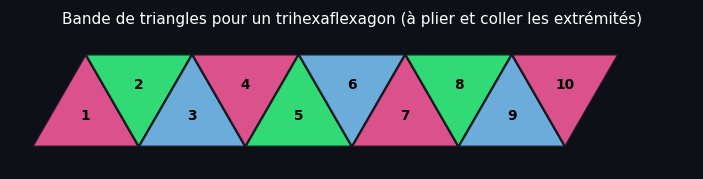

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import math

fig, ax = plt.subplots(figsize=(8,2.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
h = math.sqrt(3)/2
colors = ["#ff5da2","#39ff88","#7ec8ff"]
for i in range(10):
    x0 = i*0.5
    pts = [(x0,0),(x0+1,0),(x0+0.5,h)] if i % 2 == 0 else [(x0,h),(x0+1,h),(x0+0.5,0)]
    ax.add_patch(Polygon(pts, closed=True, facecolor=colors[i%3], edgecolor="#0d1117", linewidth=1.5, alpha=0.85))
    cx, cy = sum(p[0] for p in pts)/3, sum(p[1] for p in pts)/3
    ax.text(cx, cy, str(i+1), ha="center", va="center", color="black", fontsize=9, fontweight="bold")
ax.set_xlim(-0.2, 6.2); ax.set_ylim(-0.2, h+0.2)
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Bande de 10 triangles pour un trihexaflexagon", color="white", fontsize=10)
plt.show()


## 2. Le Jeu de la Vie de Conway <a id="2"></a>

Gardner consacre sa chronique d'octobre 1970 à un automate cellulaire inventé par John Conway : le
**Jeu de la Vie**. Trois règles suffisent — une cellule vivante avec 2 ou 3 voisines survit, une cellule
morte avec exactement 3 voisines naît, tout le reste meurt — pour engendrer une richesse de comportements
que Gardner qualifiera de calcul quasi universel émergeant de règles triviales. Ci-dessous : un
**planeur** (glider), le motif mobile le plus simple.

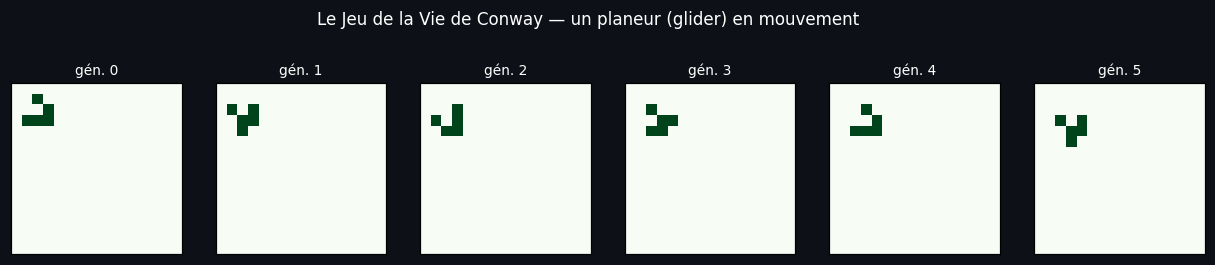

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def step(grid):
    n = np.zeros_like(grid)
    for dr in (-1,0,1):
        for dc in (-1,0,1):
            if dr==0 and dc==0: continue
            n += np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
    return ((grid==1)&((n==2)|(n==3))) | ((grid==0)&(n==3))

size = 16
grid = np.zeros((size,size), dtype=int)
for r,c in [(1,2),(2,3),(3,1),(3,2),(3,3)]:
    grid[r,c] = 1

fig, axes = plt.subplots(1,6, figsize=(14,2.6), facecolor="#0d1117")
for i,ax in enumerate(axes):
    ax.set_facecolor("#0d1117")
    ax.imshow(grid, cmap="Greens", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"gén. {i}", color="white", fontsize=9)
    grid = step(grid).astype(int)
fig.suptitle("Un planeur (glider) en mouvement", color="white", fontsize=11, y=1.05)
plt.show()


## 3. Pentominos <a id="3"></a>

Gardner popularise les **pentominos** (les 12 formes obtenues en assemblant 5 carrés bord à bord) dans sa
chronique de mai 1957, reprenant le terme inventé par Solomon Golomb. Défi classique : paver un rectangle
avec les 12 pièces sans trou ni chevauchement. Ci-dessous, les 12 pentominos, puis une solution calculée
par recherche avec retour arrière (*backtracking*) pour un rectangle **6×10** (parmi les 9356 solutions
connues).

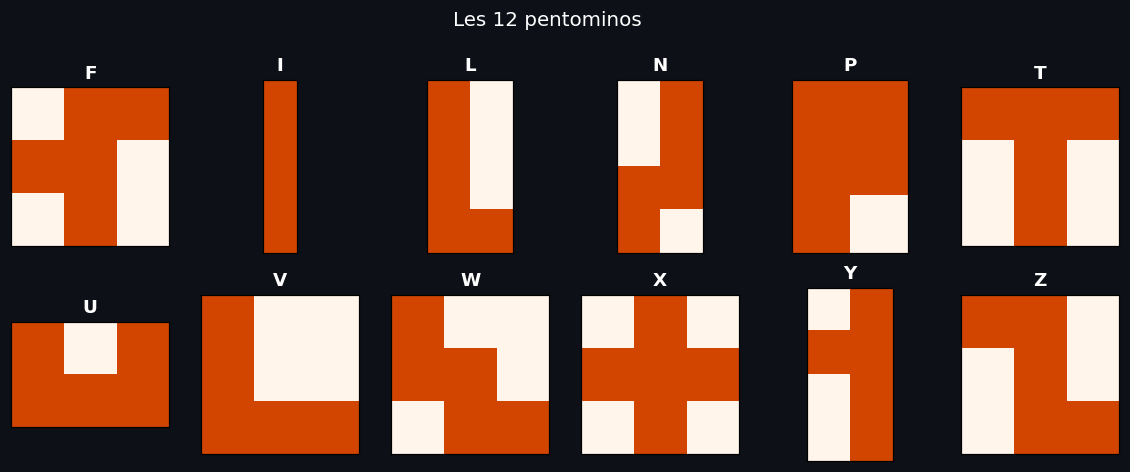

In [3]:
PENTOMINOES = {
 'F': [(0,1),(0,2),(1,0),(1,1),(2,1)], 'I': [(0,0),(1,0),(2,0),(3,0),(4,0)],
 'L': [(0,0),(1,0),(2,0),(3,0),(3,1)], 'N': [(0,1),(1,1),(2,0),(2,1),(3,0)],
 'P': [(0,0),(0,1),(1,0),(1,1),(2,0)], 'T': [(0,0),(0,1),(0,2),(1,1),(2,1)],
 'U': [(0,0),(0,2),(1,0),(1,1),(1,2)], 'V': [(0,0),(1,0),(2,0),(2,1),(2,2)],
 'W': [(0,0),(1,0),(1,1),(2,1),(2,2)], 'X': [(0,1),(1,0),(1,1),(1,2),(2,1)],
 'Y': [(0,1),(1,0),(1,1),(2,1),(3,1)], 'Z': [(0,0),(0,1),(1,1),(2,1),(2,2)],
}

fig, axes = plt.subplots(2,6, figsize=(13,4.5), facecolor="#0d1117")
for ax,(name,cells) in zip(axes.flat, PENTOMINOES.items()):
    ax.set_facecolor("#0d1117")
    maxr = max(r for r,c in cells)+1; maxc = max(c for r,c in cells)+1
    grid = np.zeros((maxr,maxc))
    for r,c in cells: grid[r,c] = 1
    ax.imshow(grid, cmap="Oranges", vmin=0, vmax=1.3)
    ax.set_title(name, color="white", fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Les 12 pentominos", color="white", fontsize=13, y=1.02)
plt.show()


In [4]:
def normalize(cells):
    minr = min(r for r,c in cells); minc = min(c for r,c in cells)
    return tuple(sorted((r-minr,c-minc) for r,c in cells))

def variants(cells):
    vs, p = set(), cells
    for flip in range(2):
        p = [(r,-c) for r,c in cells] if flip else cells
        for rot in range(4):
            p = [(c,-r) for r,c in p]
            vs.add(normalize(p))
    return [list(v) for v in vs]

ALL_VARIANTS = {name: variants(cells) for name,cells in PENTOMINOES.items()}
ROWS, COLS = 6, 10

def solve():
    board = [[None]*COLS for _ in range(ROWS)]
    pieces_left = list(PENTOMINOES.keys())

    def find_empty():
        for r in range(ROWS):
            for c in range(COLS):
                if board[r][c] is None: return r,c
        return None

    def region_ok():
        seen = [[False]*COLS for _ in range(ROWS)]
        for r in range(ROWS):
            for c in range(COLS):
                if board[r][c] is None and not seen[r][c]:
                    stack, size = [(r,c)], 0
                    seen[r][c] = True
                    while stack:
                        cr,cc = stack.pop(); size += 1
                        for dr,dc in ((1,0),(-1,0),(0,1),(0,-1)):
                            nr,nc = cr+dr, cc+dc
                            if 0<=nr<ROWS and 0<=nc<COLS and board[nr][nc] is None and not seen[nr][nc]:
                                seen[nr][nc] = True; stack.append((nr,nc))
                    if size % 5 != 0: return False
        return True

    def backtrack():
        empty = find_empty()
        if empty is None: return True
        r,c = empty
        for name in list(pieces_left):
            for shape in ALL_VARIANTS[name]:
                for (br,bc) in shape:
                    cells = [(r+(sr-br), c+(sc-bc)) for sr,sc in shape]
                    if all(0<=cr<ROWS and 0<=cc<COLS and board[cr][cc] is None for cr,cc in cells):
                        for cr,cc in cells: board[cr][cc] = name
                        pieces_left.remove(name)
                        if region_ok() and backtrack():
                            return True
                        for cr,cc in cells: board[cr][cc] = None
                        pieces_left.append(name)
        return False

    backtrack()
    return board

board = solve()
for row in board:
    print(' '.join(row))


F F I I I I I L Z Z
V F F Y L L L L Z N
V F Y Y Y Y X Z Z N
V V V T W X X X N N
P P P T W W X U N U
P P T T T W W U U U


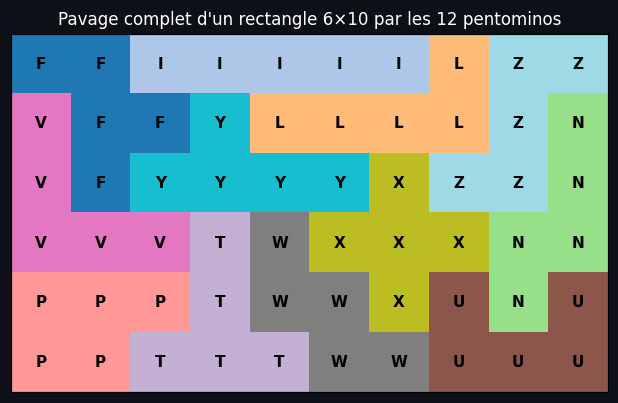

In [5]:
names = sorted(PENTOMINOES.keys())
name_to_idx = {n:i for i,n in enumerate(names)}
arr = np.array([[name_to_idx[c] for c in row] for row in board])

fig, ax = plt.subplots(figsize=(7,4.4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.imshow(arr, cmap="tab20")
for r in range(ROWS):
    for c in range(COLS):
        ax.text(c, r, board[r][c], ha="center", va="center", color="black", fontsize=10, fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Pavage complet d'un rectangle 6×10 par les 12 pentominos", color="white", fontsize=11)
plt.show()


## 4. Carrés magiques <a id="4"></a>

Sujet de prédilection de Gardner, qui y consacre plusieurs chroniques (et tout un livre, *Mathematical
Circus*). Un **carré magique** d'ordre $n$ contient les entiers $1$ à $n^2$ tels que chaque ligne, colonne
et diagonale ait la même somme. Pour les ordres impairs, la **méthode siamoise** (De la Loubère, XVIIe
siècle) construit un carré magique en une seule passe, presque par magie.

[[30 39 48  1 10 19 28]
 [38 47  7  9 18 27 29]
 [46  6  8 17 26 35 37]
 [ 5 14 16 25 34 36 45]
 [13 15 24 33 42 44  4]
 [21 23 32 41 43  3 12]
 [22 31 40 49  2 11 20]]
Constante magique : 175


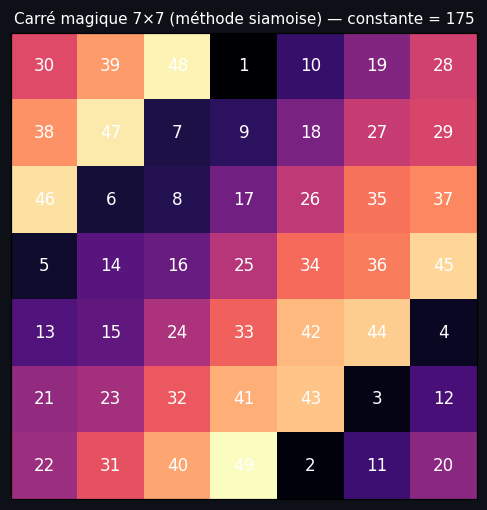

In [6]:
def siamese(n):
    sq = np.zeros((n,n), dtype=int)
    i, j = 0, n//2
    for num in range(1, n*n+1):
        sq[i,j] = num
        ni, nj = (i-1)%n, (j+1)%n
        if sq[ni,nj]:
            ni, nj = (i+1)%n, j
        i, j = ni, nj
    return sq

n = 7
sq = siamese(n)
print(sq)
print("Constante magique :", sq[0,:].sum())

fig, ax = plt.subplots(figsize=(5.5,5.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.imshow(sq, cmap="magma")
for r in range(n):
    for c in range(n):
        ax.text(c, r, sq[r,c], ha="center", va="center", color="white", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Carré magique {n}×{n} (méthode siamoise) — constante = {sq[0,:].sum()}", color="white", fontsize=10)
plt.show()


## 5. Le Cube Soma <a id="5"></a>

Inventé par Piet Hein pendant une conférence de physique quantique en 1933 (!), le **cube Soma** est
constitué de 7 pièces — les 6 tétracubes irréguliers plus un tricube en L — qui doivent se combiner pour
former un cube $3\times3\times3$. Gardner en fait la vedette de sa chronique de septembre 1958, déclenchant
un engouement mondial. Ci-dessous, une solution trouvée par recherche exhaustive sur les 24 rotations de
chaque pièce.

Cube rempli : 27 / 27 cellules, avec les 7 pièces ['V', 'L', 'T', 'Z', 'A', 'B', 'P']


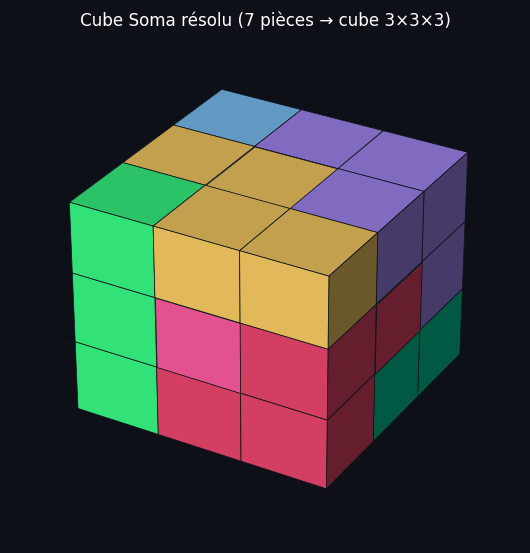

In [7]:
PIECES = {
 'V': [(0,0,0),(1,0,0),(1,1,0)],
 'L': [(0,0,0),(1,0,0),(2,0,0),(2,1,0)],
 'T': [(0,0,0),(1,0,0),(2,0,0),(1,1,0)],
 'Z': [(0,0,0),(0,1,0),(1,1,0),(1,2,0)],
 'A': [(0,0,0),(0,1,0),(1,1,0),(1,1,1)],
 'B': [(0,0,0),(1,0,0),(1,1,0),(1,1,1)],
 'P': [(0,0,0),(0,1,0),(1,0,0),(0,0,1)],
}

def rotations24():
    def rotx(p): x,y,z=p; return (x,-z,y)
    def roty(p): x,y,z=p; return (z,y,-x)
    base = ((1,0,0),(0,1,0),(0,0,1))
    def transform(basis, f): return tuple(f(v) for v in basis)
    frontier, seenb, gens = [base], {base}, [rotx, roty]
    while frontier:
        nb = []
        for b in frontier:
            for g in gens:
                nb2 = transform(b, g)
                if nb2 not in seenb:
                    seenb.add(nb2); nb.append(nb2)
        frontier = nb
    return list(seenb)

ROT_BASES = rotations24()

def apply_basis(cells, basis):
    ex,ey,ez = basis; out = []
    for x,y,z in cells:
        vx = tuple(x*ex[i] for i in range(3)); vy = tuple(y*ey[i] for i in range(3)); vz = tuple(z*ez[i] for i in range(3))
        out.append(tuple(vx[i]+vy[i]+vz[i] for i in range(3)))
    return out

def normalize3(cells):
    mx=min(c[0] for c in cells); my=min(c[1] for c in cells); mz=min(c[2] for c in cells)
    return tuple(sorted((c[0]-mx,c[1]-my,c[2]-mz) for c in cells))

ALL_OR = {}
for name,cells in PIECES.items():
    vs = set()
    for basis in ROT_BASES: vs.add(normalize3(apply_basis(cells,basis)))
    ALL_OR[name] = [list(v) for v in vs]

N = 3
def solve_soma():
    grid, order = {}, sorted(PIECES.keys(), key=lambda k: -len(PIECES[k]))
    def find_empty():
        for x in range(N):
            for y in range(N):
                for z in range(N):
                    if (x,y,z) not in grid: return (x,y,z)
        return None
    def backtrack(remaining):
        cell = find_empty()
        if cell is None: return True
        x,y,z = cell
        for name in remaining:
            for shape in ALL_OR[name]:
                for (bx,by,bz) in shape:
                    placed = [(x+(sx-bx), y+(sy-by), z+(sz-bz)) for sx,sy,sz in shape]
                    if all(0<=px<N and 0<=py<N and 0<=pz<N and (px,py,pz) not in grid for px,py,pz in placed):
                        for p in placed: grid[p] = name
                        if backtrack([r for r in remaining if r!=name]):
                            return True
                        for p in placed: del grid[p]
        return False
    backtrack(order)
    return grid

grid = solve_soma()
print(f"Cube rempli : {len(grid)} / 27 cellules, avec les 7 pièces {list(PIECES.keys())}")

fig = plt.figure(figsize=(6,6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection='3d', facecolor="#0d1117")
colors_map = {'V':'#ff5da2','L':'#39ff88','T':'#7ec8ff','Z':'#ffd166','A':'#ef476f','B':'#06d6a0','P':'#a78bfa'}
voxels = np.zeros((3,3,3), dtype=bool)
colarr = np.empty((3,3,3), dtype=object)
for (x,y,z),name in grid.items():
    voxels[x,y,z] = True
    colarr[x,y,z] = colors_map[name]
ax.voxels(voxels, facecolors=colarr, edgecolor="#0d1117", linewidth=0.5)
ax.set_axis_off()
ax.set_title("Cube Soma résolu (7 pièces → cube 3×3×3)", color="white", fontsize=11)
plt.show()


## 6. Cryptographie à clé publique (RSA) <a id="6"></a>

En août 1977, Gardner consacre sa chronique à un "nouveau type de chiffrement qui prendrait des millions
d'années à casser" — la toute première présentation grand public de ce qui deviendra **RSA**, tout juste
inventé par Rivest, Shamir et Adleman (et encore non breveté). L'article inclut même un défi de
déchiffrement, **RSA-129**, qui ne sera résolu qu'en 1994, 17 ans plus tard, par calcul distribué.

Voici le principe, avec des nombres jouets (à ne surtout pas utiliser en pratique !).

In [8]:
p, q = 61, 53          # deux nombres premiers (secrets)
n = p * q              # module public
phi = (p-1) * (q-1)    # indicatrice d'Euler (secrète)
e = 17                 # exposant public
d = pow(e, -1, phi)    # exposant privé (inverse modulaire de e)

print(f"p={p}  q={q}  n={n}  phi(n)={phi}")
print(f"clé publique  (n, e) = ({n}, {e})")
print(f"clé privée    (n, d) = ({n}, {d})")

message = 65   # 'A' en ASCII — doit être < n
cipher = pow(message, e, n)      # chiffrement : c = m^e mod n
decoded = pow(cipher, d, n)      # déchiffrement : m = c^d mod n

print(f"\nmessage clair m={message}  →  chiffré c={cipher}  →  déchiffré m'={decoded}")


p=61  q=53  n=3233  phi(n)=3120
clé publique  (n, e) = (3233, 17)
clé privée    (n, d) = (3233, 2753)

message clair m=65  →  chiffré c=2790  →  déchiffré m'=65


## 7. Le jeu de Nim <a id="7"></a>

Gardner adorait ce jeu ancestral (plusieurs tas d'allumettes, chaque joueur retire au moins une allumette
d'un seul tas, le dernier à jouer gagne), notamment parce qu'il possède une **stratégie gagnante
explicite** : calculer le XOR binaire (le "nim-sum") des tailles des tas. Si le nim-sum est non nul, il
existe toujours un coup ramenant à un nim-sum nul — position perdante pour l'adversaire.

Simulation : un joueur "optimal" (suit la stratégie XOR) contre un joueur qui joue au hasard.

In [9]:
import random
random.seed(7)

heaps = [3,4,5]
print("Nim, tas de départ :", heaps)
turn, history = 0, []

while any(h>0 for h in heaps):
    nim_sum = 0
    for h in heaps: nim_sum ^= h
    player = "Ordinateur (optimal)" if turn%2==0 else "Adversaire (aléatoire)"
    if turn % 2 == 0:
        for i,h in enumerate(heaps):
            target = h ^ nim_sum
            if target < h:
                history.append((player, i, h-target)); heaps[i] = target
                break
        else:
            for i,h in enumerate(heaps):
                if h>0:
                    heaps[i] -= 1; history.append((player, i, 1)); break
    else:
        nz = [i for i,h in enumerate(heaps) if h>0]
        i = random.choice(nz)
        take = random.randint(1, heaps[i])
        heaps[i] -= take
        history.append((player, i, take))
    turn += 1

for player, i, take in history:
    print(f"{player} retire {take} du tas {i}")
print("\nVainqueur (dernier à jouer) :", history[-1][0])


Nim, tas de départ : [3, 4, 5]
Ordinateur (optimal) retire 2 du tas 0
Adversaire (aléatoire) retire 2 du tas 1
Ordinateur (optimal) retire 2 du tas 2
Adversaire (aléatoire) retire 1 du tas 1
Ordinateur (optimal) retire 3 du tas 2
Adversaire (aléatoire) retire 1 du tas 0
Ordinateur (optimal) retire 1 du tas 1

Vainqueur (dernier à jouer) : Ordinateur (optimal)


## 8. Pavages de Penrose <a id="8"></a>

En janvier 1977, Gardner présente au grand public la découverte de Roger Penrose : des jeux de tuiles
(cerfs-volants/fléchettes, ou losanges) qui pavent le plan **sans jamais se répéter périodiquement**, tout
en gardant une symétrie d'ordre 5 globale. Une décennie plus tard, ces pavages "impossibles" trouveront un
écho physique inattendu avec la découverte des quasicristaux (prix Nobel de chimie 2011).

Génération ci-dessous par la **méthode de la pentagrille** de N.G. de Bruijn : cinq familles de droites
parallèles, dont le graphe dual donne directement le pavage de losanges.

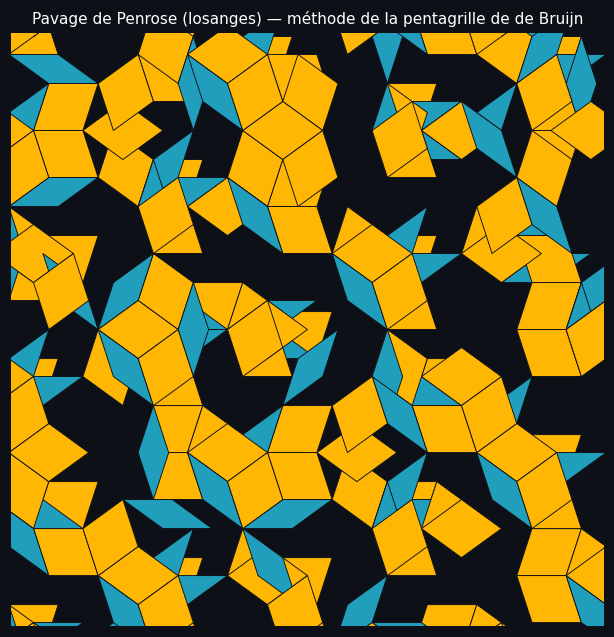

In [10]:
import math
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

theta = [2*np.pi*j/5 for j in range(5)]
gamma = [0.13, 0.27, 0.06, -0.11, 0.31]   # décalages génériques (évite les intersections dégénérées)

def line_val(x, y, j):
    return x*np.cos(theta[j]) + y*np.sin(theta[j])

nmax = 5
patches, colors = [], []
for j in range(5):
    for k in range(j+1, 5):
        A = np.array([[np.cos(theta[j]), np.sin(theta[j])], [np.cos(theta[k]), np.sin(theta[k])]])
        Ainv = np.linalg.inv(A)
        for nj in range(-nmax, nmax+1):
            for nk in range(-nmax, nmax+1):
                b = np.array([nj - gamma[j], nk - gamma[k]])
                x, y = Ainv.dot(b)
                if x*x + y*y > 36:
                    continue
                Kbase = {m: math.ceil(line_val(x,y,m) - gamma[m]) for m in range(5) if m not in (j,k)}
                verts = []
                for dnj in (0,1):
                    for dnk in (0,1):
                        K = dict(Kbase); K[j] = nj+dnj; K[k] = nk+dnk
                        vx = sum(K[m]*np.cos(theta[m]) for m in range(5))
                        vy = sum(K[m]*np.sin(theta[m]) for m in range(5))
                        verts.append((vx, vy))
                cx = sum(v[0] for v in verts)/4; cy = sum(v[1] for v in verts)/4
                verts.sort(key=lambda v: math.atan2(v[1]-cy, v[0]-cx))
                patches.append(Polygon(verts, closed=True))
                colors.append((k-j) % 5)

cmap_colors = ["#ffb703" if c in (1,4) else "#219ebc" for c in colors]
fig, ax = plt.subplots(figsize=(7,7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
pc = PatchCollection(patches, facecolor=cmap_colors, edgecolor="#0d1117", linewidths=0.6)
ax.add_collection(pc)
ax.set_xlim(-6,6); ax.set_ylim(-6,6)
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title(f"Pavage de Penrose ({len(patches)} losanges) — méthode de la pentagrille", color="white", fontsize=10)
plt.show()


## 9. Le paradoxe de Monty Hall <a id="9"></a>

Gardner avait déjà exploré des paradoxes de probabilités voisins avant même la célébrité du problème via
la chronique de Marilyn vos Savant en 1990 — la question du "problème des trois prisonniers" qu'il pose
en 1959 en est une formulation quasi identique. Trois portes, une voiture, deux chèvres : après le choix
du candidat, l'animateur ouvre une porte perdante parmi les deux restantes. Faut-il changer de porte ?
La réponse — oui, cela double les chances de gain — heurte l'intuition de presque tout le monde,
Gardner y compris à l'origine, ce qui en fait un excellent cas d'école.

Taux de victoire final en changeant : 0.668  (théorique 2/3 = 0.667)
Taux de victoire final en restant   : 0.332  (théorique 1/3 = 0.333)


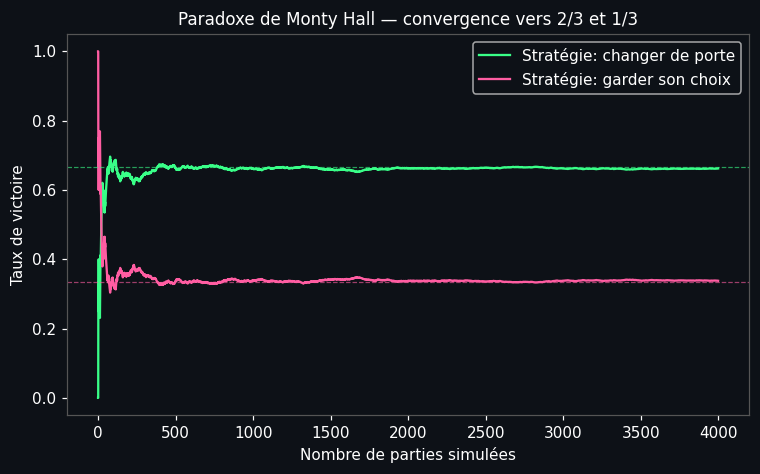

In [11]:
rng = np.random.default_rng(42)
N = 4000
doors = rng.integers(0,3,size=N)     # porte gagnante
choice = rng.integers(0,3,size=N)    # choix initial du candidat

switch_wins = (doors != choice)      # en changeant, on gagne ssi le choix initial était FAUX
stay_wins   = (doors == choice)      # en restant, on gagne ssi le choix initial était BON

switch_rate = np.cumsum(switch_wins) / np.arange(1, N+1)
stay_rate   = np.cumsum(stay_wins)   / np.arange(1, N+1)

print(f"Taux de victoire final en changeant : {switch_rate[-1]:.3f}  (théorique 2/3 = {2/3:.3f})")
print(f"Taux de victoire final en restant   : {stay_rate[-1]:.3f}  (théorique 1/3 = {1/3:.3f})")

fig, ax = plt.subplots(figsize=(8,4.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(switch_rate, color="#39ff88", label="Stratégie : changer de porte")
ax.plot(stay_rate, color="#ff5da2", label="Stratégie : garder son choix")
ax.axhline(2/3, color="#39ff88", ls="--", lw=0.8, alpha=0.6)
ax.axhline(1/3, color="#ff5da2", ls="--", lw=0.8, alpha=0.6)
ax.set_xlabel("Nombre de parties simulées", color="white")
ax.set_ylabel("Taux de victoire", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white")
ax.set_title("Paradoxe de Monty Hall — convergence vers 2/3 et 1/3", color="white", fontsize=11)
plt.show()


## 10. Bac à sable interactif <a id="10"></a>

Pour la démo live : un slider `ipywidgets` pour rejouer le Jeu de la Vie génération par génération sur un
motif au choix, et un second pour explorer différentes densités du pavage de Penrose. Idéal pour montrer
qu'un notebook Jupyter est un vrai labo interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider, Dropdown

PATTERNS = {
    "Planeur (glider)": [(1,2),(2,3),(3,1),(3,2),(3,3)],
    "Clignotant (blinker)": [(3,2),(3,3),(3,4)],
    "Crapaud (toad)": [(3,3),(3,4),(3,5),(4,2),(4,3),(4,4)],
}

def show_life(pattern="Planeur (glider)", generation=0):
    size = 20
    grid = np.zeros((size,size), dtype=int)
    for r,c in PATTERNS[pattern]:
        grid[r,c] = 1
    for _ in range(generation):
        grid = step(grid).astype(int)
    fig, ax = plt.subplots(figsize=(5,5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.imshow(grid, cmap="Greens", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{pattern} — génération {generation}", color="white")
    plt.show()

interact(show_life,
         pattern=Dropdown(options=list(PATTERNS.keys())),
         generation=IntSlider(0, min=0, max=30, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Martin Gardner**, *The Colossal Book of Mathematics* (2001) — la meilleure anthologie de ses chroniques
- **Martin Gardner**, *Hexaflexagons and Other Mathematical Diversions* (1959) — son tout premier recueil
- **Martin Gardner**, *Mathematical Circus* (1979) — carrés magiques, pavages, et bien plus
- **Martin Gardner**, *Penrose Tiles to Trapdoor Ciphers* (1989) — Penrose et RSA dans le même livre
- [The Mathematical Gardner](https://www.g4g4.com) — la communauté "Gathering 4 Gardner" qui perpétue son esprit

---
*Notebook généré pour une démo JupyterLab, en écho au notebook Pickover — libre à toi de piocher, couper,
ou dupliquer les cellules selon le public visé.*
